Loading and splitting all datasets into training and testing sets...
Training MLP_Clean...
Training MLP_CTSP...
Training MLP_MMSE...
Running exhaustive cross-condition testing...
Data saved to CSV: evaluation_results\Comprehensive_Metrics.csv


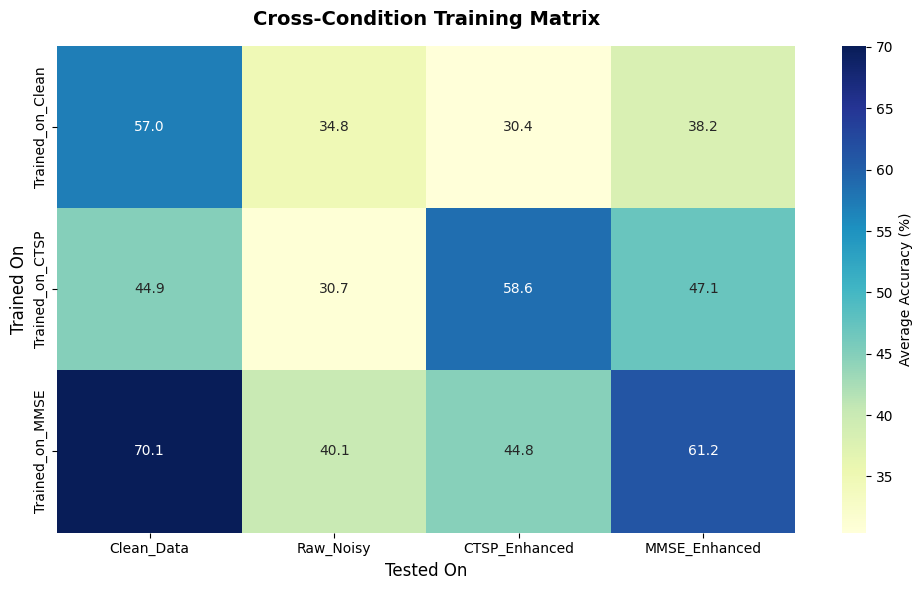

Master matrix plot saved to: evaluation_results\Training_Cross_Matrix.png
All combinations executed and logged.


In [ ]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings

warnings.filterwarnings('ignore')

CLEAN_DIR = "Extracted_Features_Clean"
NOISY_DIR = "Extracted_Features_Noisy"
PAPER_DIR = "Extracted_Features_PAPER"
MMSE_DIR = "Extracted_Features_MMSE"
MODEL_DIR = "models"
RESULTS_DIR = "evaluation_results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TARGET_NAMES = ["Anger (W)", "Boredom (L)", "Disgust (E)", "Anxiety/Fear (A)", "Happiness (F)", "Sadness (T)", "Neutral (N)"]

def load_and_split(x_path, y_path, test_size=0.2):
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        return None, None, None, None
        
    x_data = np.load(x_path)
    y_data = np.load(y_path)
    
    return train_test_split(x_data, y_data, test_size=test_size, stratify=y_data, random_state=42)

def collect_dataset(directory):
    x_train_list = []
    y_train_list = []
    test_dictionary = {}
    
    if not os.path.exists(directory):
        return None, None, {}
        
    for file in os.listdir(directory):
        if file.startswith("X_") and file.endswith(".npy"):
            environment_name = file[2:-4] 
            x_path = os.path.join(directory, file)
            y_path = os.path.join(directory, f"Y_{environment_name}.npy")
            
            x_train, x_test, y_train, y_test = load_and_split(x_path, y_path)
            
            if x_train is not None:
                x_train_list.append(x_train)
                y_train_list.append(y_train)
                test_dictionary[environment_name] = (x_test, y_test)
                
    if not x_train_list:
        return None, None, {}
        
    x_train_combined = np.vstack(x_train_list)
    y_train_combined = np.hstack(y_train_list)
    
    return x_train_combined, y_train_combined, test_dictionary

print("Loading and splitting all datasets into training and testing sets...")
x_clean_train, y_clean_train, clean_test_dict = collect_dataset(CLEAN_DIR)
x_noisy_train, y_noisy_train, noisy_test_dict = collect_dataset(NOISY_DIR)
x_ctsp_train, y_ctsp_train, ctsp_test_dict = collect_dataset(PAPER_DIR)
x_mmse_train, y_mmse_train, mmse_test_dict = collect_dataset(MMSE_DIR)

def train_neural_network(x_train, y_train, model_name):
    print(f"Training {model_name}...")
    
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(256, 128), 
        activation='relu', 
        solver='adam', 
        max_iter=500, 
        random_state=42, 
        early_stopping=True
    )
    
    mlp_model.fit(x_train, y_train)
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pkl")
    with open(model_path, 'wb') as file:
        pickle.dump(mlp_model, file)
        
    return mlp_model

trained_models = {}

if x_clean_train is not None: 
    trained_models["Trained_on_Clean"] = train_neural_network(x_clean_train, y_clean_train, "MLP_Clean")
    
if x_ctsp_train is not None:  
    trained_models["Trained_on_CTSP"] = train_neural_network(x_ctsp_train, y_ctsp_train, "MLP_CTSP")
    
if x_mmse_train is not None:  
    trained_models["Trained_on_MMSE"] = train_neural_network(x_mmse_train, y_mmse_train, "MLP_MMSE")

print("Running exhaustive cross-condition testing...")

all_test_environments = {
    "Clean_Data": clean_test_dict,
    "Raw_Noisy": noisy_test_dict,
    "CTSP_Enhanced": ctsp_test_dict,
    "MMSE_Enhanced": mmse_test_dict
}

master_metrics_list = []
heatmap_data = {model_name: {"Clean_Data": [], "Raw_Noisy": [], "CTSP_Enhanced": [], "MMSE_Enhanced": []} for model_name in trained_models.keys()}

for model_name, model in trained_models.items():
    for condition_type, test_dictionary in all_test_environments.items():
        for environment_name, (x_test, y_test) in test_dictionary.items():
            
            predictions = model.predict(x_test)
            overall_accuracy = accuracy_score(y_test, predictions)
            
            heatmap_data[model_name][condition_type].append(overall_accuracy)
            
            unique_labels = np.unique(y_test)
            active_targets = [TARGET_NAMES[index] for index in unique_labels]
            
            classification_metrics = classification_report(y_test, predictions, target_names=active_targets, output_dict=True, zero_division=0)
            
            for class_name, metrics in classification_metrics.items():
                if class_name == 'accuracy':
                    continue
                    
                if class_name in ['macro avg', 'weighted avg']:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name.upper(),
                        "Precision": metrics.get('precision', 0),
                        "Recall": metrics.get('recall', 0),
                        "F1_Score": metrics.get('f1-score', 0),
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                else:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name,
                        "Precision": metrics['precision'],
                        "Recall": metrics['recall'],
                        "F1_Score": metrics['f1-score'],
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                master_metrics_list.append(row_data)

metrics_dataframe = pd.DataFrame(master_metrics_list)

excel_output_path = os.path.join(RESULTS_DIR, "Comprehensive_Metrics.xlsx")
csv_output_path = os.path.join(RESULTS_DIR, "Comprehensive_Metrics.csv")

try:
    metrics_dataframe.to_excel(excel_output_path, index=False)
    print(f"Data saved to Excel: {excel_output_path}")
except ImportError:
    metrics_dataframe.to_csv(csv_output_path, index=False)
    print(f"Data saved to CSV: {csv_output_path}")

aggregated_heatmap_matrix = np.zeros((len(trained_models), 4))
y_axis_labels = list(trained_models.keys())
x_axis_labels = ["Clean_Data", "Raw_Noisy", "CTSP_Enhanced", "MMSE_Enhanced"]

for row_index, model_name in enumerate(y_axis_labels):
    for col_index, condition_type in enumerate(x_axis_labels):
        if len(heatmap_data[model_name][condition_type]) > 0:
            aggregated_heatmap_matrix[row_index, col_index] = np.mean(heatmap_data[model_name][condition_type]) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    aggregated_heatmap_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    xticklabels=x_axis_labels, 
    yticklabels=y_axis_labels, 
    cbar_kws={'label': 'Average Accuracy (%)'}
)

plt.title("Cross-Condition Training Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tested On", fontsize=12)
plt.ylabel("Trained On", fontsize=12)
plt.tight_layout()

plot_output_path = os.path.join(RESULTS_DIR, "Training_Cross_Matrix.png")
plt.savefig(plot_output_path, dpi=300)
plt.show()

print(f"Master matrix plot saved to: {plot_output_path}")
print("All combinations executed and logged.")

Loading and splitting all datasets into training and testing sets...

Initializing SVM pipeline for LINEAR kernel...
Training SVM_LINEAR_Clean (Kernel: linear)...
Training SVM_LINEAR_CTSP (Kernel: linear)...
Training SVM_LINEAR_MMSE (Kernel: linear)...

Initializing SVM pipeline for RBF kernel...
Training SVM_RBF_Clean (Kernel: rbf)...
Training SVM_RBF_CTSP (Kernel: rbf)...
Training SVM_RBF_MMSE (Kernel: rbf)...

Running exhaustive cross-condition testing for all SVM combinations...

Data saved to CSV: evaluation_results\Comprehensive_SVM_Metrics.csv


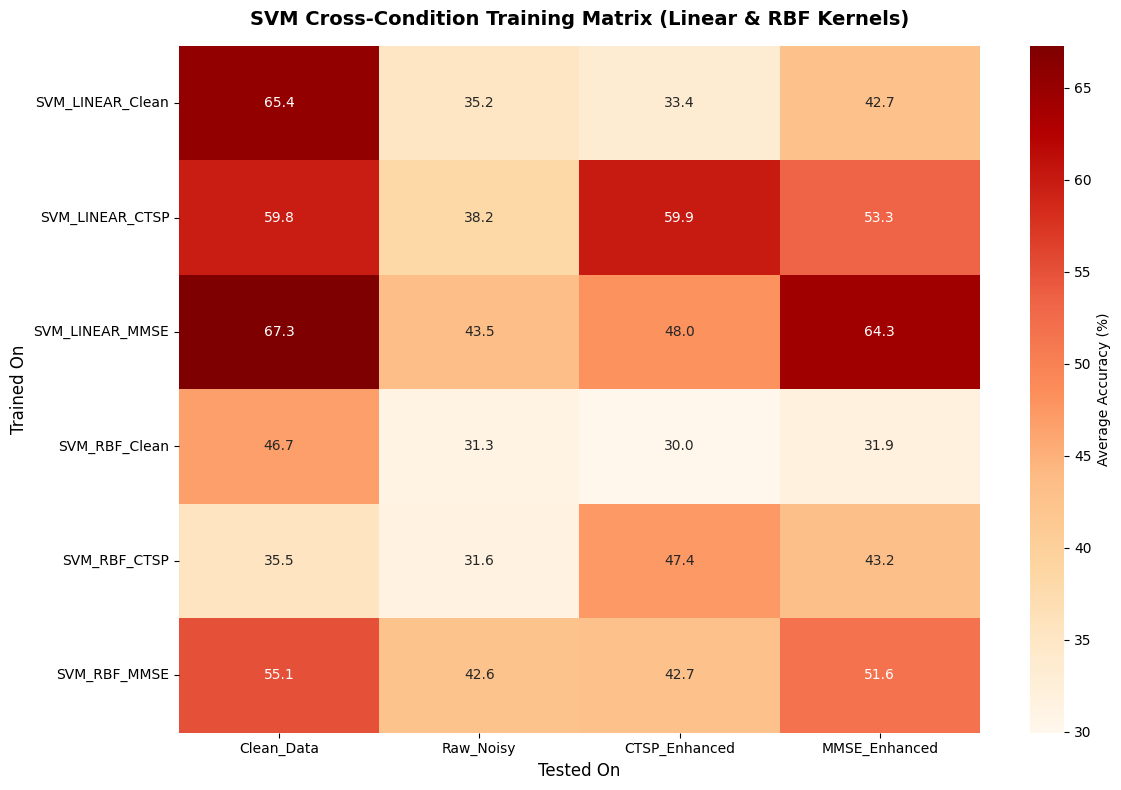

Master matrix plot saved to: evaluation_results\SVM_Training_Cross_Matrix.png
All SVM combinations executed and logged.


In [2]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings

warnings.filterwarnings('ignore')

CLEAN_DIR = "Extracted_Features_Clean"
NOISY_DIR = "Extracted_Features_Noisy"
PAPER_DIR = "Extracted_Features_PAPER"
MMSE_DIR = "Extracted_Features_MMSE"
MODEL_DIR = "models"
RESULTS_DIR = "evaluation_results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TARGET_NAMES = ["Anger (W)", "Boredom (L)", "Disgust (E)", "Anxiety/Fear (A)", "Happiness (F)", "Sadness (T)", "Neutral (N)"]

def load_and_split(x_path, y_path, test_size=0.2):
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        return None, None, None, None
        
    x_data = np.load(x_path)
    y_data = np.load(y_path)
    
    return train_test_split(x_data, y_data, test_size=test_size, stratify=y_data, random_state=42)

def collect_dataset(directory):
    x_train_list = []
    y_train_list = []
    test_dictionary = {}
    
    if not os.path.exists(directory):
        return None, None, {}
        
    for file in os.listdir(directory):
        if file.startswith("X_") and file.endswith(".npy"):
            environment_name = file[2:-4] 
            x_path = os.path.join(directory, file)
            y_path = os.path.join(directory, f"Y_{environment_name}.npy")
            
            x_train, x_test, y_train, y_test = load_and_split(x_path, y_path)
            
            if x_train is not None:
                x_train_list.append(x_train)
                y_train_list.append(y_train)
                test_dictionary[environment_name] = (x_test, y_test)
                
    if not x_train_list:
        return None, None, {}
        
    x_train_combined = np.vstack(x_train_list)
    y_train_combined = np.hstack(y_train_list)
    
    return x_train_combined, y_train_combined, test_dictionary

print("Loading and splitting all datasets into training and testing sets...")
x_clean_train, y_clean_train, clean_test_dict = collect_dataset(CLEAN_DIR)
x_noisy_train, y_noisy_train, noisy_test_dict = collect_dataset(NOISY_DIR)
x_ctsp_train, y_ctsp_train, ctsp_test_dict = collect_dataset(PAPER_DIR)
x_mmse_train, y_mmse_train, mmse_test_dict = collect_dataset(MMSE_DIR)

def train_svm_model(x_train, y_train, model_name, kernel_type):
    print(f"Training {model_name} (Kernel: {kernel_type})...")
    
    svm_model = SVC(kernel=kernel_type, random_state=42)
    svm_model.fit(x_train, y_train)
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pkl")
    with open(model_path, 'wb') as file:
        pickle.dump(svm_model, file)
        
    return svm_model

trained_models = {}

kernel_options = ['linear', 'rbf']

for kernel in kernel_options:
    print(f"\nInitializing SVM pipeline for {kernel.upper()} kernel...")
    
    if x_clean_train is not None: 
        model_name = f"SVM_{kernel.upper()}_Clean"
        trained_models[model_name] = train_svm_model(x_clean_train, y_clean_train, model_name, kernel)
        
    if x_ctsp_train is not None:  
        model_name = f"SVM_{kernel.upper()}_CTSP"
        trained_models[model_name] = train_svm_model(x_ctsp_train, y_ctsp_train, model_name, kernel)
        
    if x_mmse_train is not None:  
        model_name = f"SVM_{kernel.upper()}_MMSE"
        trained_models[model_name] = train_svm_model(x_mmse_train, y_mmse_train, model_name, kernel)

print("\nRunning exhaustive cross-condition testing for all SVM combinations...")

all_test_environments = {
    "Clean_Data": clean_test_dict,
    "Raw_Noisy": noisy_test_dict,
    "CTSP_Enhanced": ctsp_test_dict,
    "MMSE_Enhanced": mmse_test_dict
}

master_metrics_list = []
heatmap_data = {model_name: {"Clean_Data": [], "Raw_Noisy": [], "CTSP_Enhanced": [], "MMSE_Enhanced": []} for model_name in trained_models.keys()}

for model_name, model in trained_models.items():
    for condition_type, test_dictionary in all_test_environments.items():
        for environment_name, (x_test, y_test) in test_dictionary.items():
            
            predictions = model.predict(x_test)
            overall_accuracy = accuracy_score(y_test, predictions)
            
            heatmap_data[model_name][condition_type].append(overall_accuracy)
            
            unique_labels = np.unique(y_test)
            active_targets = [TARGET_NAMES[index] for index in unique_labels]
            
            classification_metrics = classification_report(y_test, predictions, target_names=active_targets, output_dict=True, zero_division=0)
            
            for class_name, metrics in classification_metrics.items():
                if class_name == 'accuracy':
                    continue
                    
                if class_name in ['macro avg', 'weighted avg']:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name.upper(),
                        "Precision": metrics.get('precision', 0),
                        "Recall": metrics.get('recall', 0),
                        "F1_Score": metrics.get('f1-score', 0),
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                else:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name,
                        "Precision": metrics['precision'],
                        "Recall": metrics['recall'],
                        "F1_Score": metrics['f1-score'],
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                master_metrics_list.append(row_data)

metrics_dataframe = pd.DataFrame(master_metrics_list)

excel_output_path = os.path.join(RESULTS_DIR, "Comprehensive_SVM_Metrics.xlsx")
csv_output_path = os.path.join(RESULTS_DIR, "Comprehensive_SVM_Metrics.csv")

try:
    metrics_dataframe.to_excel(excel_output_path, index=False)
    print(f"\nData saved to Excel: {excel_output_path}")
except ImportError:
    metrics_dataframe.to_csv(csv_output_path, index=False)
    print(f"\nData saved to CSV: {csv_output_path}")

aggregated_heatmap_matrix = np.zeros((len(trained_models), 4))
y_axis_labels = list(trained_models.keys())
x_axis_labels = ["Clean_Data", "Raw_Noisy", "CTSP_Enhanced", "MMSE_Enhanced"]

for row_index, model_name in enumerate(y_axis_labels):
    for col_index, condition_type in enumerate(x_axis_labels):
        if len(heatmap_data[model_name][condition_type]) > 0:
            aggregated_heatmap_matrix[row_index, col_index] = np.mean(heatmap_data[model_name][condition_type]) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(
    aggregated_heatmap_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="OrRd", 
    xticklabels=x_axis_labels, 
    yticklabels=y_axis_labels, 
    cbar_kws={'label': 'Average Accuracy (%)'}
)

plt.title("SVM Cross-Condition Training Matrix (Linear & RBF Kernels)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tested On", fontsize=12)
plt.ylabel("Trained On", fontsize=12)
plt.tight_layout()

plot_output_path = os.path.join(RESULTS_DIR, "SVM_Training_Cross_Matrix.png")
plt.savefig(plot_output_path, dpi=300)
plt.show()

print(f"Master matrix plot saved to: {plot_output_path}")
print("All SVM combinations executed and logged.")

Loading and splitting all datasets into training and testing sets...

Initializing pipeline for Random Forest...
Training Ensemble_Random_Forest_Clean...
Training Ensemble_Random_Forest_CTSP...
Training Ensemble_Random_Forest_MMSE...

Initializing pipeline for Gradient Boosting...
Training Ensemble_Gradient_Boosting_Clean...
Training Ensemble_Gradient_Boosting_CTSP...
Training Ensemble_Gradient_Boosting_MMSE...

Running exhaustive cross-condition testing for all Ensemble combinations...

Data saved to CSV: evaluation_results\Comprehensive_Ensemble_Metrics.csv


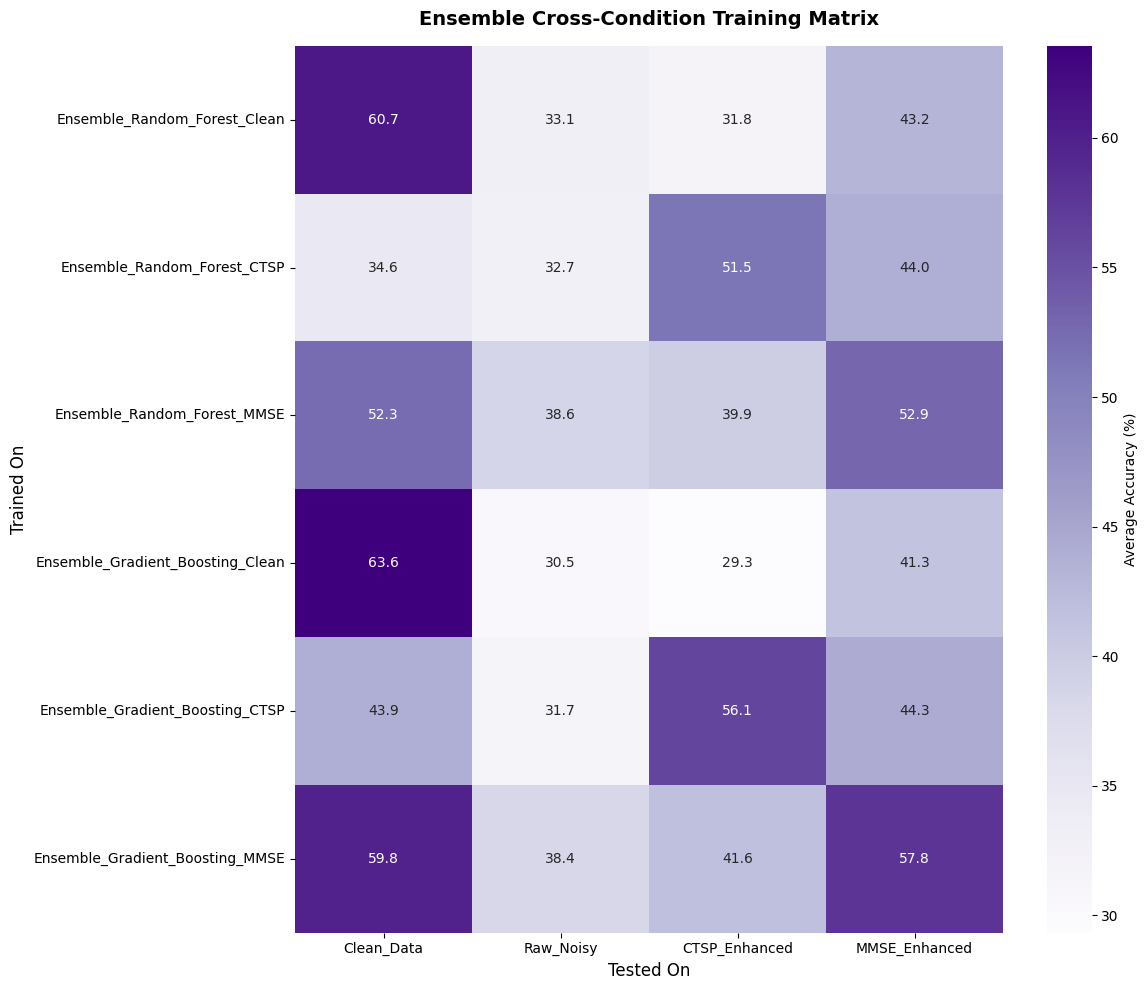

Master matrix plot saved to: evaluation_results\Ensemble_Training_Cross_Matrix.png
All Ensemble combinations executed and logged.


In [3]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings

warnings.filterwarnings('ignore')

CLEAN_DIR = "Extracted_Features_Clean"
NOISY_DIR = "Extracted_Features_Noisy"
PAPER_DIR = "Extracted_Features_PAPER"
MMSE_DIR = "Extracted_Features_MMSE"
MODEL_DIR = "models"
RESULTS_DIR = "evaluation_results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TARGET_NAMES = ["Anger (W)", "Boredom (L)", "Disgust (E)", "Anxiety/Fear (A)", "Happiness (F)", "Sadness (T)", "Neutral (N)"]

def load_and_split(x_path, y_path, test_size=0.2):
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        return None, None, None, None
        
    x_data = np.load(x_path)
    y_data = np.load(y_path)
    
    return train_test_split(x_data, y_data, test_size=test_size, stratify=y_data, random_state=42)

def collect_dataset(directory):
    x_train_list = []
    y_train_list = []
    test_dictionary = {}
    
    if not os.path.exists(directory):
        return None, None, {}
        
    for file in os.listdir(directory):
        if file.startswith("X_") and file.endswith(".npy"):
            environment_name = file[2:-4] 
            x_path = os.path.join(directory, file)
            y_path = os.path.join(directory, f"Y_{environment_name}.npy")
            
            x_train, x_test, y_train, y_test = load_and_split(x_path, y_path)
            
            if x_train is not None:
                x_train_list.append(x_train)
                y_train_list.append(y_train)
                test_dictionary[environment_name] = (x_test, y_test)
                
    if not x_train_list:
        return None, None, {}
        
    x_train_combined = np.vstack(x_train_list)
    y_train_combined = np.hstack(y_train_list)
    
    return x_train_combined, y_train_combined, test_dictionary

print("Loading and splitting all datasets into training and testing sets...")
x_clean_train, y_clean_train, clean_test_dict = collect_dataset(CLEAN_DIR)
x_noisy_train, y_noisy_train, noisy_test_dict = collect_dataset(NOISY_DIR)
x_ctsp_train, y_ctsp_train, ctsp_test_dict = collect_dataset(PAPER_DIR)
x_mmse_train, y_mmse_train, mmse_test_dict = collect_dataset(MMSE_DIR)

def train_ensemble_model(x_train, y_train, model_name, model_type):
    print(f"Training {model_name}...")
    
    if model_type == 'random_forest':
        ensemble_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif model_type == 'gradient_boosting':
        ensemble_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
        
    ensemble_model.fit(x_train, y_train)
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pkl")
    with open(model_path, 'wb') as file:
        pickle.dump(ensemble_model, file)
        
    return ensemble_model

trained_models = {}

ensemble_options = ['random_forest', 'gradient_boosting']

for algorithm in ensemble_options:
    print(f"\nInitializing pipeline for {algorithm.replace('_', ' ').title()}...")
    
    if x_clean_train is not None: 
        model_name = f"Ensemble_{algorithm.title()}_Clean"
        trained_models[model_name] = train_ensemble_model(x_clean_train, y_clean_train, model_name, algorithm)
        
    if x_ctsp_train is not None:  
        model_name = f"Ensemble_{algorithm.title()}_CTSP"
        trained_models[model_name] = train_ensemble_model(x_ctsp_train, y_ctsp_train, model_name, algorithm)
        
    if x_mmse_train is not None:  
        model_name = f"Ensemble_{algorithm.title()}_MMSE"
        trained_models[model_name] = train_ensemble_model(x_mmse_train, y_mmse_train, model_name, algorithm)

print("\nRunning exhaustive cross-condition testing for all Ensemble combinations...")

all_test_environments = {
    "Clean_Data": clean_test_dict,
    "Raw_Noisy": noisy_test_dict,
    "CTSP_Enhanced": ctsp_test_dict,
    "MMSE_Enhanced": mmse_test_dict
}

master_metrics_list = []
heatmap_data = {model_name: {"Clean_Data": [], "Raw_Noisy": [], "CTSP_Enhanced": [], "MMSE_Enhanced": []} for model_name in trained_models.keys()}

for model_name, model in trained_models.items():
    for condition_type, test_dictionary in all_test_environments.items():
        for environment_name, (x_test, y_test) in test_dictionary.items():
            
            predictions = model.predict(x_test)
            overall_accuracy = accuracy_score(y_test, predictions)
            
            heatmap_data[model_name][condition_type].append(overall_accuracy)
            
            unique_labels = np.unique(y_test)
            active_targets = [TARGET_NAMES[index] for index in unique_labels]
            
            classification_metrics = classification_report(y_test, predictions, target_names=active_targets, output_dict=True, zero_division=0)
            
            for class_name, metrics in classification_metrics.items():
                if class_name == 'accuracy':
                    continue
                    
                if class_name in ['macro avg', 'weighted avg']:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name.upper(),
                        "Precision": metrics.get('precision', 0),
                        "Recall": metrics.get('recall', 0),
                        "F1_Score": metrics.get('f1-score', 0),
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                else:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name,
                        "Precision": metrics['precision'],
                        "Recall": metrics['recall'],
                        "F1_Score": metrics['f1-score'],
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                master_metrics_list.append(row_data)

metrics_dataframe = pd.DataFrame(master_metrics_list)

excel_output_path = os.path.join(RESULTS_DIR, "Comprehensive_Ensemble_Metrics.xlsx")
csv_output_path = os.path.join(RESULTS_DIR, "Comprehensive_Ensemble_Metrics.csv")

try:
    metrics_dataframe.to_excel(excel_output_path, index=False)
    print(f"\nData saved to Excel: {excel_output_path}")
except ImportError:
    metrics_dataframe.to_csv(csv_output_path, index=False)
    print(f"\nData saved to CSV: {csv_output_path}")

aggregated_heatmap_matrix = np.zeros((len(trained_models), 4))
y_axis_labels = list(trained_models.keys())
x_axis_labels = ["Clean_Data", "Raw_Noisy", "CTSP_Enhanced", "MMSE_Enhanced"]

for row_index, model_name in enumerate(y_axis_labels):
    for col_index, condition_type in enumerate(x_axis_labels):
        if len(heatmap_data[model_name][condition_type]) > 0:
            aggregated_heatmap_matrix[row_index, col_index] = np.mean(heatmap_data[model_name][condition_type]) * 100

plt.figure(figsize=(12, 10))
sns.heatmap(
    aggregated_heatmap_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="Purples", 
    xticklabels=x_axis_labels, 
    yticklabels=y_axis_labels, 
    cbar_kws={'label': 'Average Accuracy (%)'}
)

plt.title("Ensemble Cross-Condition Training Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tested On", fontsize=12)
plt.ylabel("Trained On", fontsize=12)
plt.tight_layout()

plot_output_path = os.path.join(RESULTS_DIR, "Ensemble_Training_Cross_Matrix.png")
plt.savefig(plot_output_path, dpi=300)
plt.show()

print(f"Master matrix plot saved to: {plot_output_path}")
print("All Ensemble combinations executed and logged.")

Loading and splitting all datasets into training and testing sets...
Training Voting Classifier Super Model: Voting_Classifier_Clean...
Training Voting Classifier Super Model: Voting_Classifier_CTSP...
Training Voting Classifier Super Model: Voting_Classifier_MMSE...
Running exhaustive cross-condition testing for the Super Model combinations...
Data saved to CSV: evaluation_results\Comprehensive_Super_Model_Metrics.csv


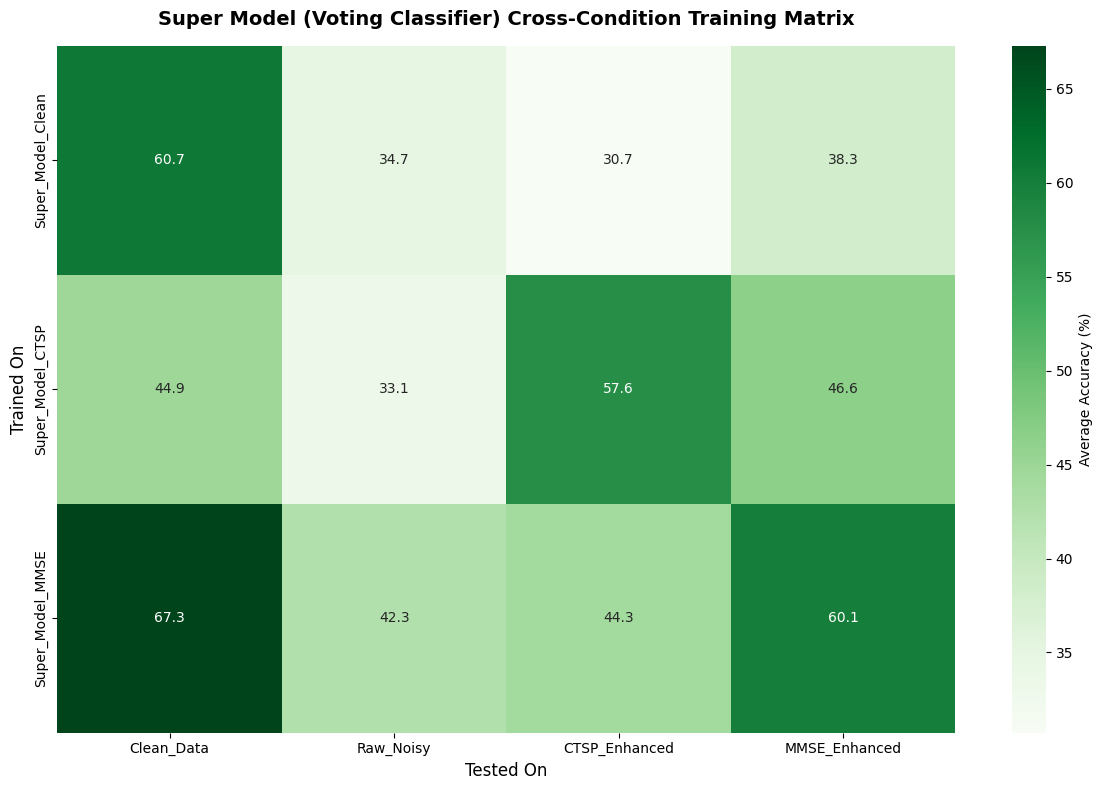

Master matrix plot saved to: evaluation_results\Super_Model_Training_Cross_Matrix.png
Super Model validation complete.


In [4]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings

warnings.filterwarnings('ignore')

CLEAN_DIR = "Extracted_Features_Clean"
NOISY_DIR = "Extracted_Features_Noisy"
PAPER_DIR = "Extracted_Features_PAPER"
MMSE_DIR = "Extracted_Features_MMSE"
MODEL_DIR = "models"
RESULTS_DIR = "evaluation_results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TARGET_NAMES = ["Anger (W)", "Boredom (L)", "Disgust (E)", "Anxiety/Fear (A)", "Happiness (F)", "Sadness (T)", "Neutral (N)"]

def load_and_split(x_path, y_path, test_size=0.2):
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        return None, None, None, None
        
    x_data = np.load(x_path)
    y_data = np.load(y_path)
    
    return train_test_split(x_data, y_data, test_size=test_size, stratify=y_data, random_state=42)

def collect_dataset(directory):
    x_train_list = []
    y_train_list = []
    test_dictionary = {}
    
    if not os.path.exists(directory):
        return None, None, {}
        
    for file in os.listdir(directory):
        if file.startswith("X_") and file.endswith(".npy"):
            environment_name = file[2:-4] 
            x_path = os.path.join(directory, file)
            y_path = os.path.join(directory, f"Y_{environment_name}.npy")
            
            x_train, x_test, y_train, y_test = load_and_split(x_path, y_path)
            
            if x_train is not None:
                x_train_list.append(x_train)
                y_train_list.append(y_train)
                test_dictionary[environment_name] = (x_test, y_test)
                
    if not x_train_list:
        return None, None, {}
        
    x_train_combined = np.vstack(x_train_list)
    y_train_combined = np.hstack(y_train_list)
    
    return x_train_combined, y_train_combined, test_dictionary

print("Loading and splitting all datasets into training and testing sets...")
x_clean_train, y_clean_train, clean_test_dict = collect_dataset(CLEAN_DIR)
x_noisy_train, y_noisy_train, noisy_test_dict = collect_dataset(NOISY_DIR)
x_ctsp_train, y_ctsp_train, ctsp_test_dict = collect_dataset(PAPER_DIR)
x_mmse_train, y_mmse_train, mmse_test_dict = collect_dataset(MMSE_DIR)

def train_super_ensemble(x_train, y_train, model_name):
    print(f"Training Voting Classifier Super Model: {model_name}...")
    
    neural_network = MLPClassifier(
        hidden_layer_sizes=(256, 128), 
        activation='relu', 
        solver='adam', 
        max_iter=500, 
        random_state=42, 
        early_stopping=True
    )
    
    support_vector = SVC(
        kernel='rbf', 
        probability=True, 
        random_state=42
    )
    
    random_forest = RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    )
    
    super_model = VotingClassifier(
        estimators=[
            ('mlp', neural_network), 
            ('svm', support_vector), 
            ('rf', random_forest)
        ], 
        voting='soft'
    )
    
    super_model.fit(x_train, y_train)
    
    model_path = os.path.join(MODEL_DIR, f"{model_name}.pkl")
    with open(model_path, 'wb') as file:
        pickle.dump(super_model, file)
        
    return super_model

trained_models = {}

if x_clean_train is not None: 
    trained_models["Super_Model_Clean"] = train_super_ensemble(x_clean_train, y_clean_train, "Voting_Classifier_Clean")
    
if x_ctsp_train is not None:  
    trained_models["Super_Model_CTSP"] = train_super_ensemble(x_ctsp_train, y_ctsp_train, "Voting_Classifier_CTSP")
    
if x_mmse_train is not None:  
    trained_models["Super_Model_MMSE"] = train_super_ensemble(x_mmse_train, y_mmse_train, "Voting_Classifier_MMSE")

print("Running exhaustive cross-condition testing for the Super Model combinations...")

all_test_environments = {
    "Clean_Data": clean_test_dict,
    "Raw_Noisy": noisy_test_dict,
    "CTSP_Enhanced": ctsp_test_dict,
    "MMSE_Enhanced": mmse_test_dict
}

master_metrics_list = []
heatmap_data = {model_name: {"Clean_Data": [], "Raw_Noisy": [], "CTSP_Enhanced": [], "MMSE_Enhanced": []} for model_name in trained_models.keys()}

for model_name, model in trained_models.items():
    for condition_type, test_dictionary in all_test_environments.items():
        for environment_name, (x_test, y_test) in test_dictionary.items():
            
            predictions = model.predict(x_test)
            overall_accuracy = accuracy_score(y_test, predictions)
            
            heatmap_data[model_name][condition_type].append(overall_accuracy)
            
            unique_labels = np.unique(y_test)
            active_targets = [TARGET_NAMES[index] for index in unique_labels]
            
            classification_metrics = classification_report(y_test, predictions, target_names=active_targets, output_dict=True, zero_division=0)
            
            for class_name, metrics in classification_metrics.items():
                if class_name == 'accuracy':
                    continue
                    
                if class_name in ['macro avg', 'weighted avg']:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name.upper(),
                        "Precision": metrics.get('precision', 0),
                        "Recall": metrics.get('recall', 0),
                        "F1_Score": metrics.get('f1-score', 0),
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                else:
                    row_data = {
                        "Training_Model": model_name,
                        "Test_Category": condition_type,
                        "Specific_Environment": environment_name,
                        "Emotion_Class": class_name,
                        "Precision": metrics['precision'],
                        "Recall": metrics['recall'],
                        "F1_Score": metrics['f1-score'],
                        "Overall_Model_Accuracy": overall_accuracy
                    }
                master_metrics_list.append(row_data)

metrics_dataframe = pd.DataFrame(master_metrics_list)

excel_output_path = os.path.join(RESULTS_DIR, "Comprehensive_Super_Model_Metrics.xlsx")
csv_output_path = os.path.join(RESULTS_DIR, "Comprehensive_Super_Model_Metrics.csv")

try:
    metrics_dataframe.to_excel(excel_output_path, index=False)
    print(f"Data saved to Excel: {excel_output_path}")
except ImportError:
    metrics_dataframe.to_csv(csv_output_path, index=False)
    print(f"Data saved to CSV: {csv_output_path}")

aggregated_heatmap_matrix = np.zeros((len(trained_models), 4))
y_axis_labels = list(trained_models.keys())
x_axis_labels = ["Clean_Data", "Raw_Noisy", "CTSP_Enhanced", "MMSE_Enhanced"]

for row_index, model_name in enumerate(y_axis_labels):
    for col_index, condition_type in enumerate(x_axis_labels):
        if len(heatmap_data[model_name][condition_type]) > 0:
            aggregated_heatmap_matrix[row_index, col_index] = np.mean(heatmap_data[model_name][condition_type]) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(
    aggregated_heatmap_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="Greens", 
    xticklabels=x_axis_labels, 
    yticklabels=y_axis_labels, 
    cbar_kws={'label': 'Average Accuracy (%)'}
)

plt.title("Super Model (Voting Classifier) Cross-Condition Training Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tested On", fontsize=12)
plt.ylabel("Trained On", fontsize=12)
plt.tight_layout()

plot_output_path = os.path.join(RESULTS_DIR, "Super_Model_Training_Cross_Matrix.png")
plt.savefig(plot_output_path, dpi=300)
plt.show()

print(f"Master matrix plot saved to: {plot_output_path}")
print("Super Model validation complete.")

#### Training on Noise data, for baseeline

Loading datasets directly from directories...

Training Voting Classifier explicitly on Raw Noisy Data...
Model saved to: models\Super_Model_RawNoisy.pkl

Testing model across all conditions...

Generating Confusion Matrix visual proofs...


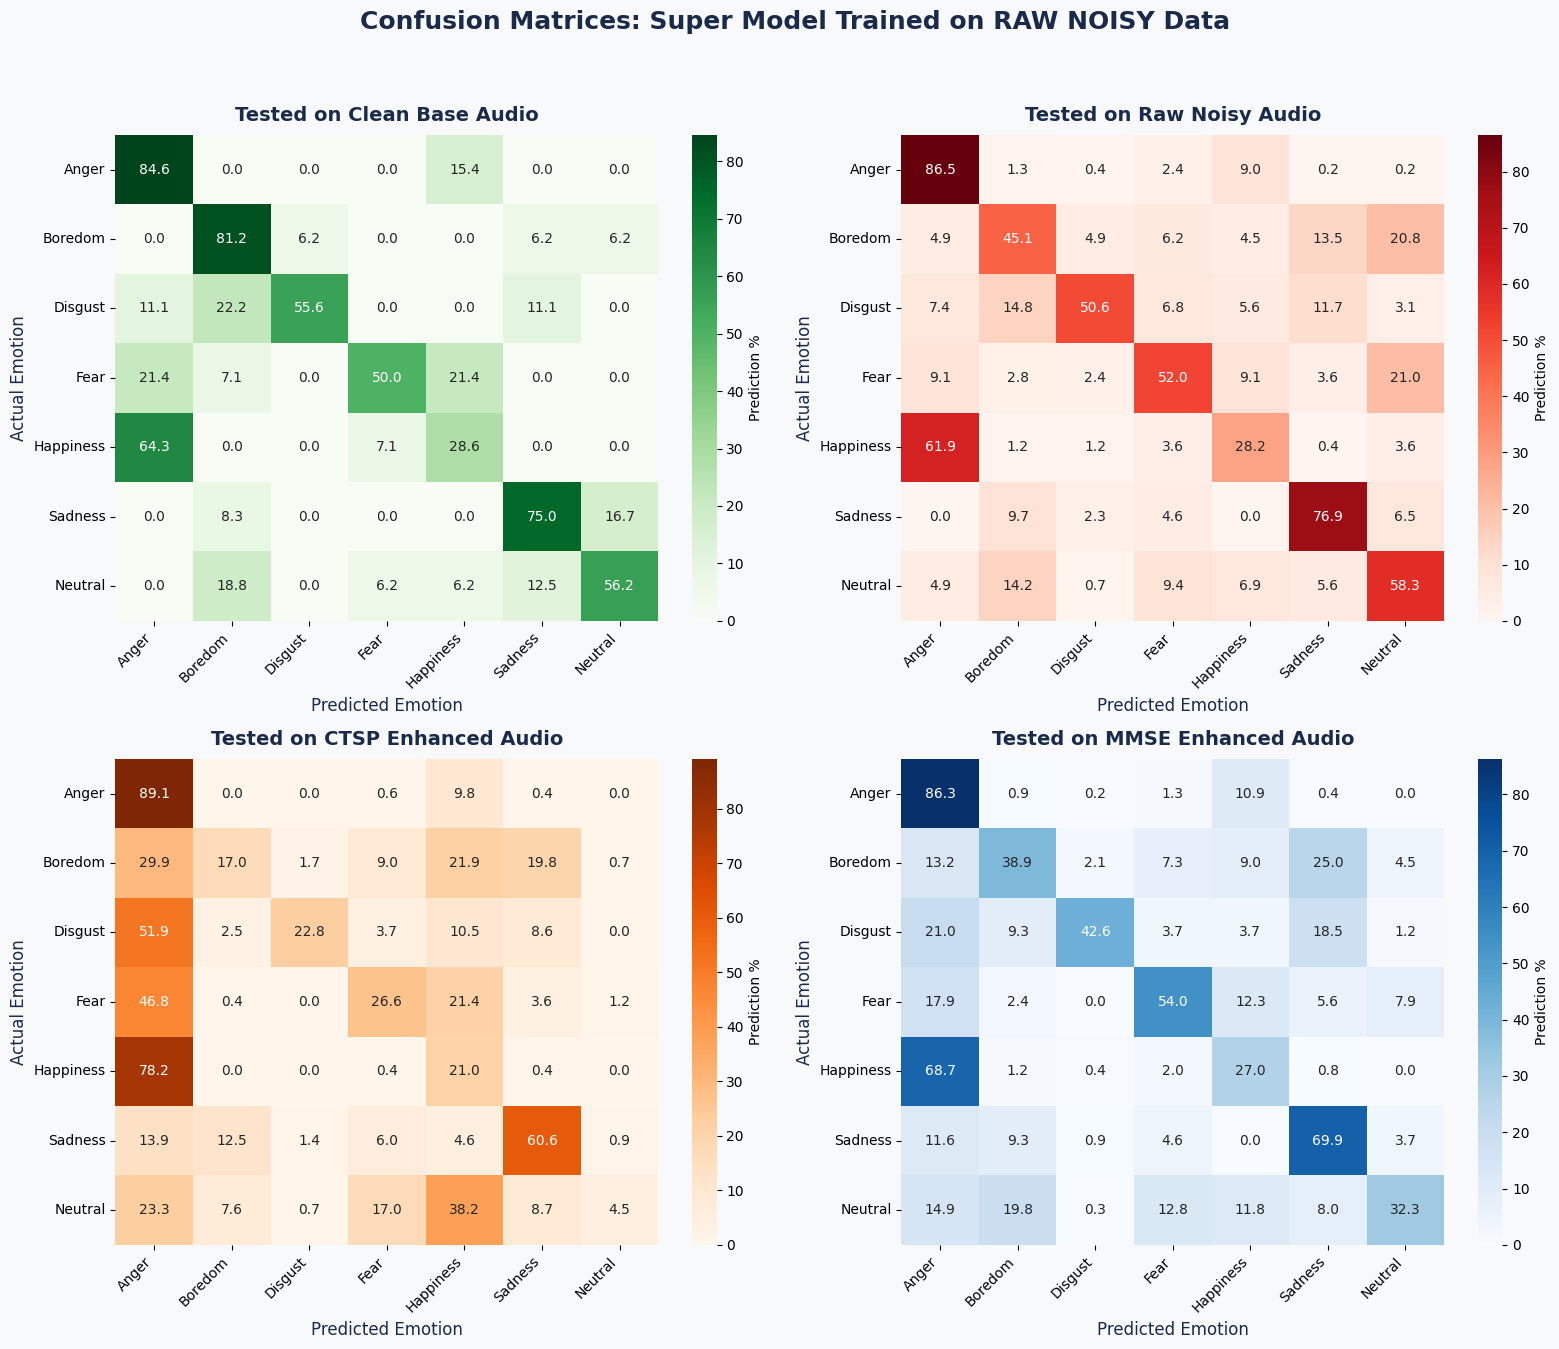

Confusion Matrix grid saved to: presentation_plots\Noisy_Trained_Confusion_Matrices.png
Process complete.


In [2]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings('ignore')

CLEAN_DIR = "Extracted_Features_Clean"
NOISY_DIR = "Extracted_Features_Noisy"
PAPER_DIR = "Extracted_Features_PAPER"
MMSE_DIR = "Extracted_Features_MMSE"
MODEL_DIR = "models"
IMG_DIR = "presentation_plots"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

TARGET_NAMES = ["Anger (W)", "Boredom (L)", "Disgust (E)", "Anxiety/Fear (A)", "Happiness (F)", "Sadness (T)", "Neutral (N)"]

def load_and_split(x_path, y_path, test_size=0.2):
    if not os.path.exists(x_path) or not os.path.exists(y_path):
        return None, None, None, None
        
    x_data = np.load(x_path)
    y_data = np.load(y_path)
    
    return train_test_split(x_data, y_data, test_size=test_size, stratify=y_data, random_state=42)

def collect_dataset(directory):
    x_train_list = []
    y_train_list = []
    test_dictionary = {}
    
    if not os.path.exists(directory):
        return None, None, {}
        
    for file in os.listdir(directory):
        if file.startswith("X_") and file.endswith(".npy"):
            environment_name = file[2:-4] 
            x_path = os.path.join(directory, file)
            y_path = os.path.join(directory, f"Y_{environment_name}.npy")
            
            x_train, x_test, y_train, y_test = load_and_split(x_path, y_path)
            
            if x_train is not None:
                x_train_list.append(x_train)
                y_train_list.append(y_train)
                test_dictionary[environment_name] = (x_test, y_test)
                
    if not x_train_list:
        return None, None, {}
        
    x_train_combined = np.vstack(x_train_list)
    y_train_combined = np.hstack(y_train_list)
    
    return x_train_combined, y_train_combined, test_dictionary

print("Loading datasets directly from directories...")
x_clean_train, y_clean_train, clean_test_dict = collect_dataset(CLEAN_DIR)
x_noisy_train, y_noisy_train, noisy_test_dict = collect_dataset(NOISY_DIR)
x_ctsp_train, y_ctsp_train, ctsp_test_dict = collect_dataset(PAPER_DIR)
x_mmse_train, y_mmse_train, mmse_test_dict = collect_dataset(MMSE_DIR)

if x_noisy_train is None:
    print("Error: Noisy training data could not be loaded. Check your Extracted_Features_Noisy directory.")
else:
    noisy_model_path = os.path.join(MODEL_DIR, "Super_Model_RawNoisy.pkl")
    
    print("\nTraining Voting Classifier explicitly on Raw Noisy Data...")
    neural_network = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam', max_iter=500, random_state=42)
    support_vector = SVC(kernel='rbf', probability=True, random_state=42)
    random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    super_model_noisy = VotingClassifier(
        estimators=[('mlp', neural_network), ('svm', support_vector), ('rf', random_forest)], 
        voting='soft'
    )
    
    super_model_noisy.fit(x_noisy_train, y_noisy_train)
    
    with open(noisy_model_path, 'wb') as file:
        pickle.dump(super_model_noisy, file)
    print(f"Model saved to: {noisy_model_path}")

    print("\nTesting model across all conditions...")
    
    all_test_environments = {
        "Tested on Clean Base Audio": clean_test_dict,
        "Tested on Raw Noisy Audio": noisy_test_dict,
        "Tested on CTSP Enhanced Audio": ctsp_test_dict,
        "Tested on MMSE Enhanced Audio": mmse_test_dict
    }
    
    confusion_matrices = {}
    
    for condition_name, test_dictionary in all_test_environments.items():
        all_y_true = []
        all_y_pred = []
        
        for environment_name, (x_test, y_test) in test_dictionary.items():
            predictions = super_model_noisy.predict(x_test)
            all_y_true.extend(y_test)
            all_y_pred.extend(predictions)
            
        if all_y_true:
            cm = confusion_matrix(all_y_true, all_y_pred)
            confusion_matrices[condition_name] = cm
    
    print("\nGenerating Confusion Matrix visual proofs...")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='#f8f9fa')
    fig.suptitle('Confusion Matrices: Super Model Trained on RAW NOISY Data', fontsize=18, fontweight='bold', color='#1a2b4a', y=0.96)
    
    axes = axes.flatten()
    colors = ['Greens', 'Reds', 'Oranges', 'Blues']
    
    short_target_names = ["Anger", "Boredom", "Disgust", "Fear", "Happiness", "Sadness", "Neutral"]
    
    for idx, (condition_name, cm) in enumerate(confusion_matrices.items()):
        ax = axes[idx]
        
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap=colors[idx], 
                    xticklabels=short_target_names, yticklabels=short_target_names, 
                    cbar_kws={'label': 'Prediction %'}, ax=ax)
        
        ax.set_title(condition_name, fontsize=14, fontweight='bold', color='#1a2b4a', pad=10)
        ax.set_xlabel('Predicted Emotion', fontsize=12, color='#1a2b4a')
        ax.set_ylabel('Actual Emotion', fontsize=12, color='#1a2b4a')
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plot_output_path = os.path.join(IMG_DIR, "Noisy_Trained_Confusion_Matrices.png")
    plt.savefig(plot_output_path, dpi=300)
    plt.show()
    
    print(f"Confusion Matrix grid saved to: {plot_output_path}")
    print("Process complete.")